In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

In [2]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 8
})

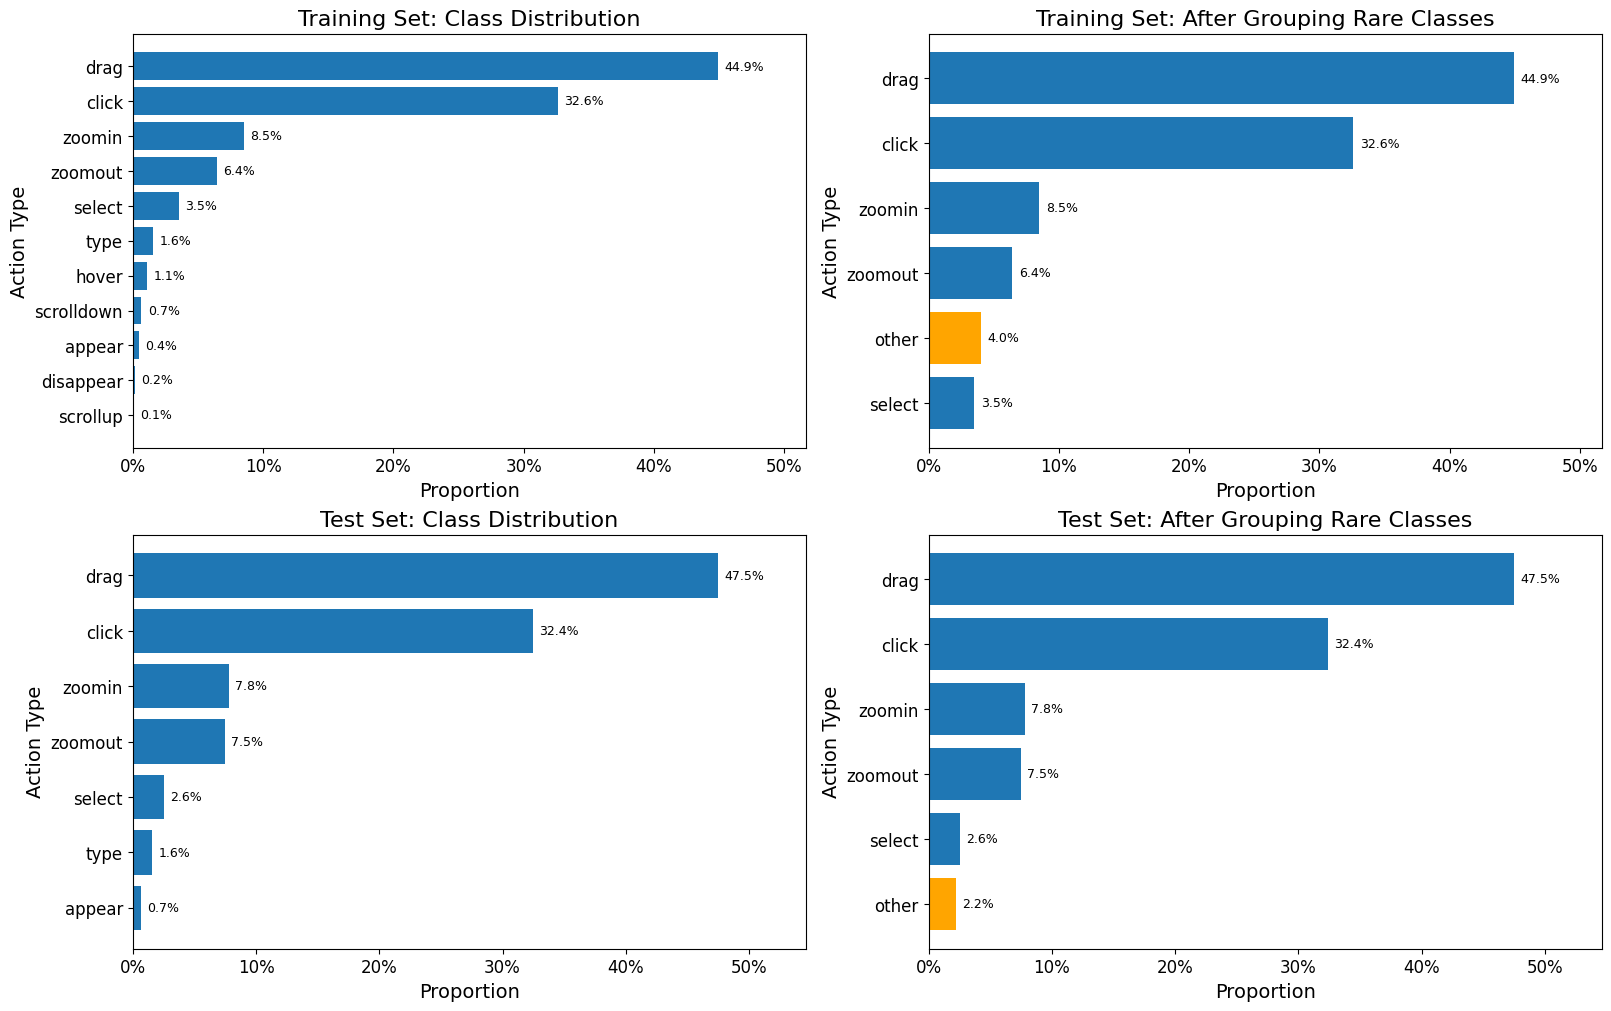

In [3]:
def class_distribution(labels):
    counts = labels.value_counts(dropna=False)
    props = counts / counts.sum()

    dist = pd.DataFrame({
        "class": counts.index.astype(str),
        "count": counts.values,
        "proportion": props.values
    }).sort_values("proportion", ascending=False).reset_index(drop=True)

    return dist


def group_rare_classes(dist_df):
    kept = dist_df[dist_df["proportion"] >= 0.025].copy()
    rare = dist_df[dist_df["proportion"] < 0.025].copy()

    if len(rare) > 0:
        other = pd.DataFrame([{
            "class": "other",
            "count": rare["count"].sum(),
            "proportion": rare["proportion"].sum()
        }])
        grouped = pd.concat([kept, other], ignore_index=True)
    else:
        grouped = kept.copy()

    grouped = grouped.sort_values("proportion", ascending=False).reset_index(drop=True)
    return grouped


def plot_distribution(ax, dist_df, title, orange_other=False):
    """
    Horizontal bar chart with percentage labels.
    If orange_other=True, the bar for 'other' is orange.
    """
    df = dist_df.sort_values("proportion", ascending=True).reset_index(drop=True)

    colors = []
    for cls in df["class"]:
        if orange_other and cls == "other":
            colors.append("orange")
        else:
            colors.append("tab:blue")

    bars = ax.barh(df["class"], df["proportion"], color=colors)

    for bar, p in zip(bars, df["proportion"]):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(x + 0.005, y, f"{p*100:.1f}%", va="center", fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("Proportion")
    ax.set_ylabel("Action Type")
    ax.set_xlim(0, max(0.5, df["proportion"].max() * 1.15))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(False)

df = pd.read_csv("data/y_train.csv")
y_train = df["label"]
df = pd.read_csv("data/y_test.csv")
y_test = df["label"]

train_dist = class_distribution(y_train)
test_dist = class_distribution(y_test)

train_grouped = group_rare_classes(train_dist)
test_grouped = group_rare_classes(test_dist)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

plot_distribution(axes[0, 0], train_dist, "Training Set: Class Distribution")
plot_distribution(axes[0, 1], train_grouped, "Training Set: After Grouping Rare Classes", orange_other=True)
plot_distribution(axes[1, 0], test_dist, "Test Set: Class Distribution")
plot_distribution(axes[1, 1], test_grouped, "Test Set: After Grouping Rare Classes", orange_other=True)

plt.savefig("figures/figure_1.pdf", dpi=400, bbox_inches="tight")
plt.show()

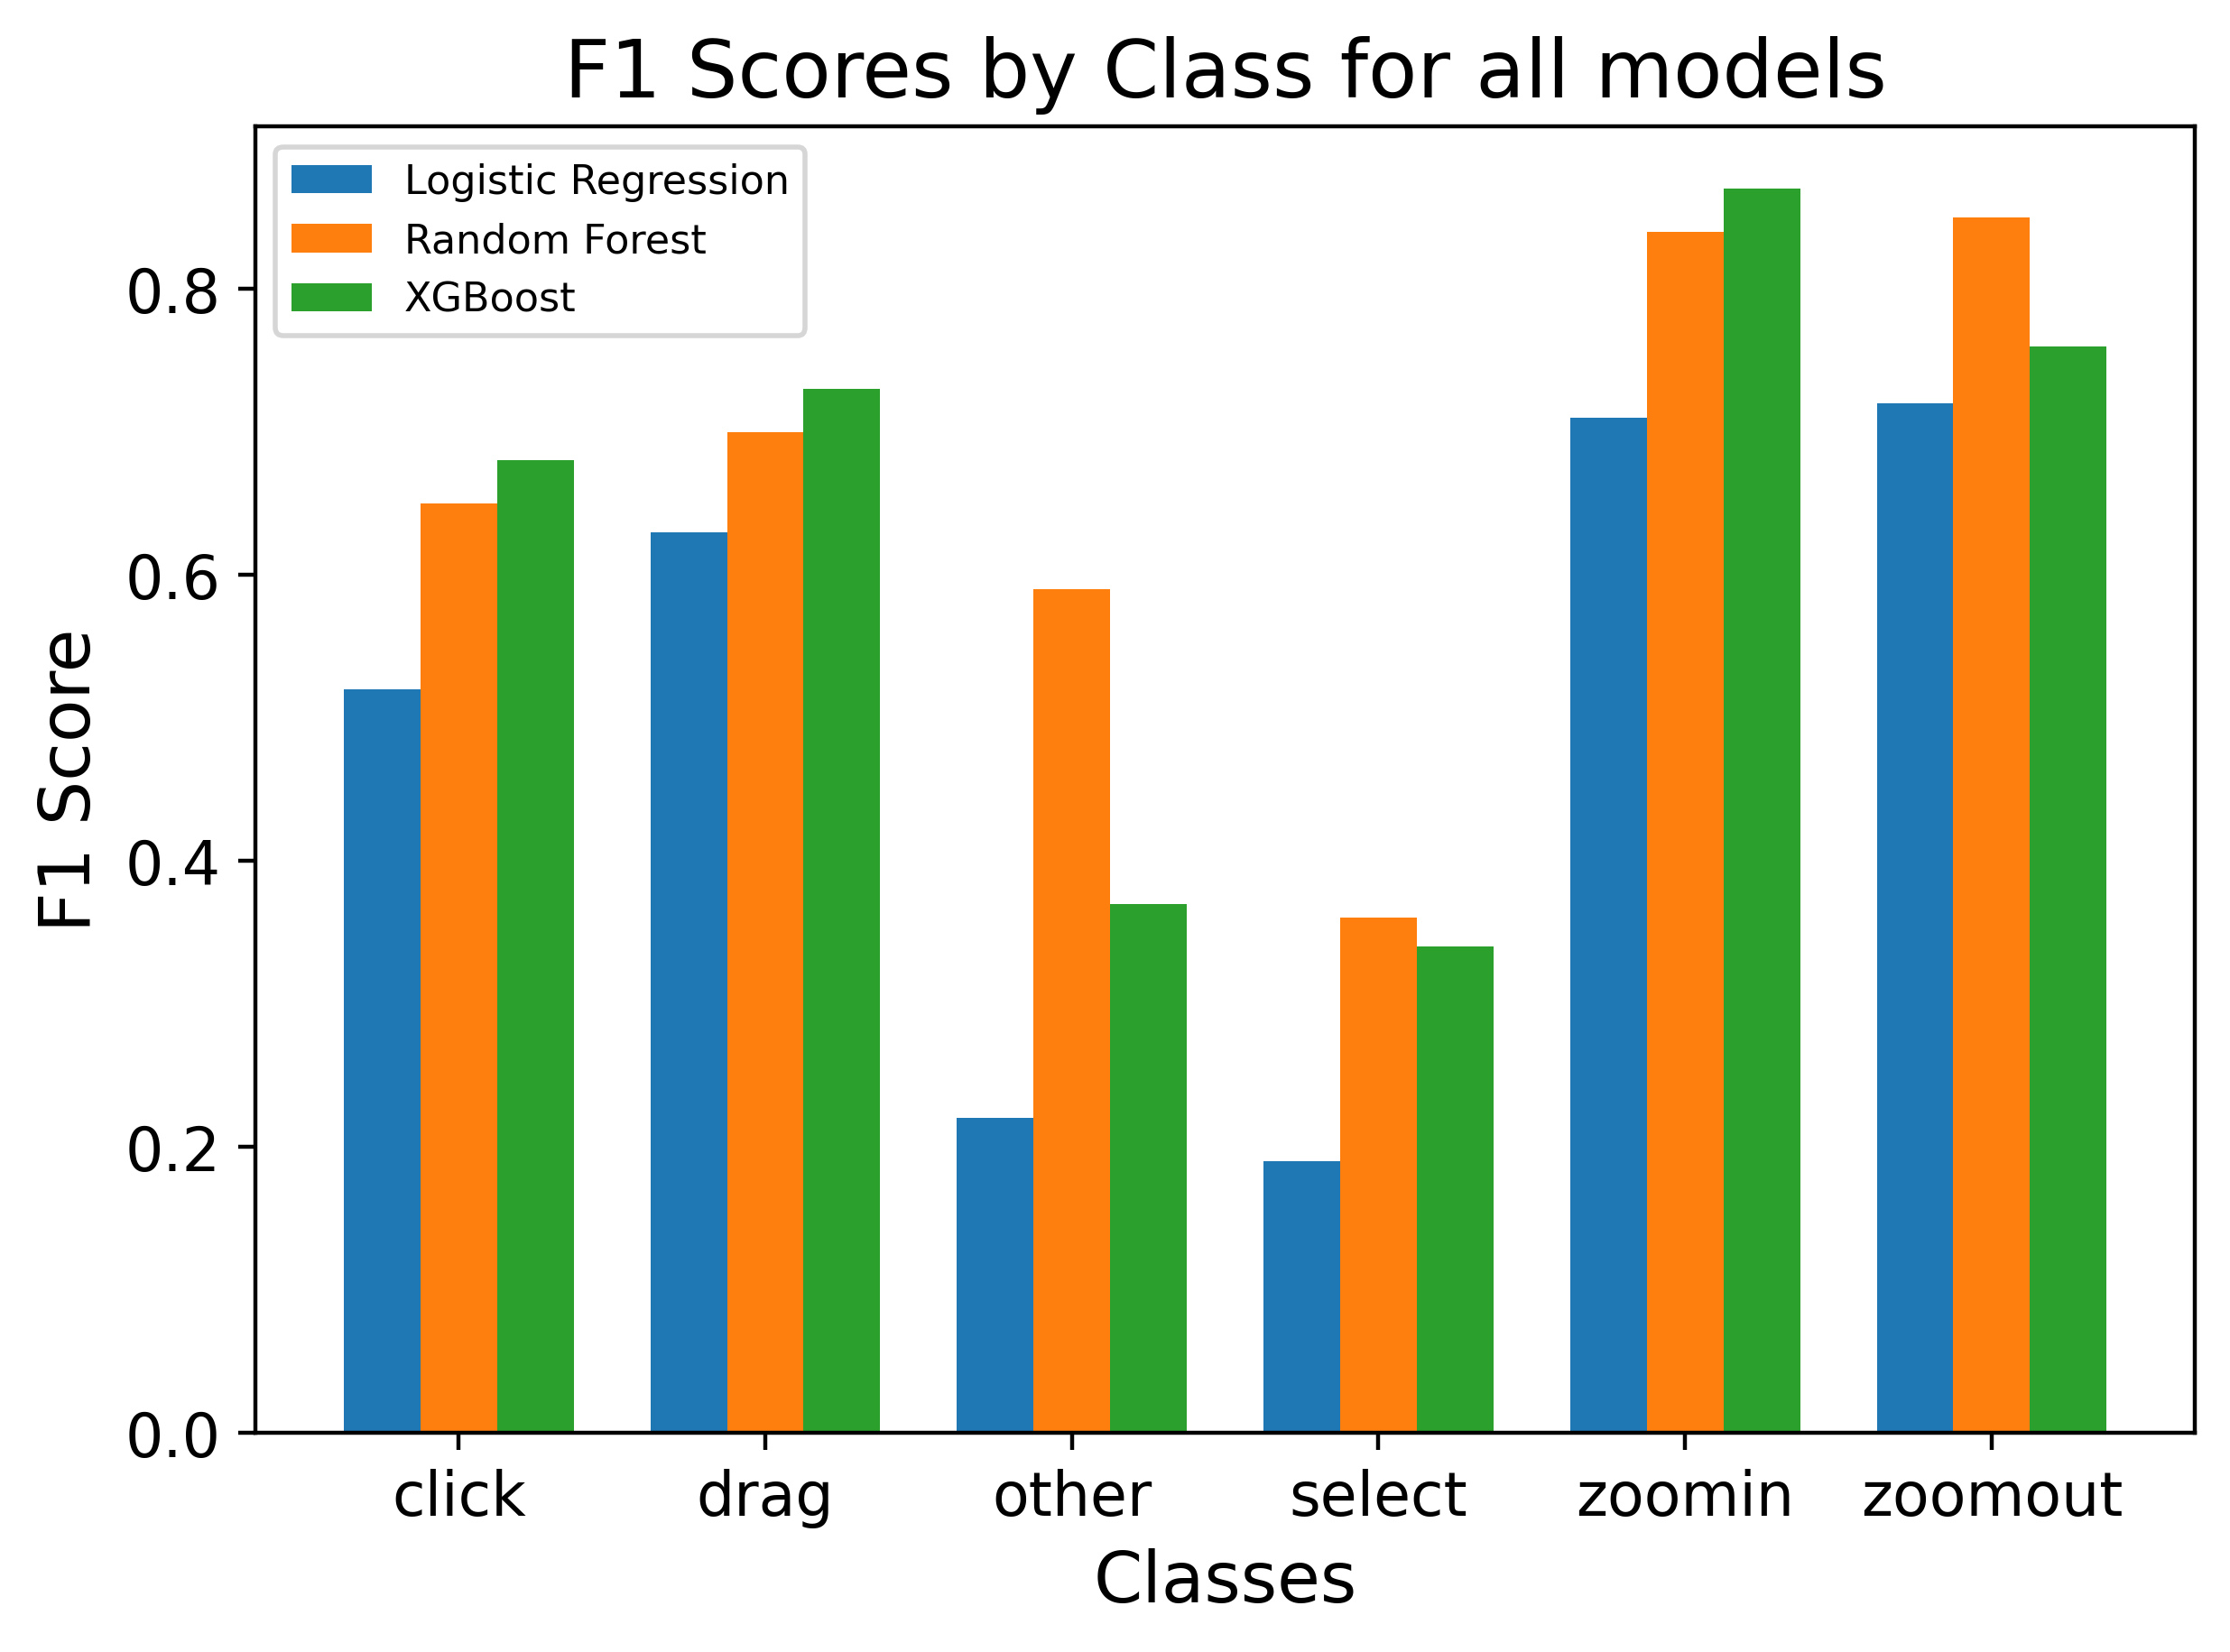

In [4]:
# Classes
classes = ['click', 'drag', 'other', 'select', 'zoomin', 'zoomout']

# F1 scores
logistic = [0.52, 0.63, 0.22, 0.19, 0.71, 0.72]
random_forest = [0.65, 0.70, 0.59, 0.36, 0.84, 0.85]
xgboost = [0.68, 0.73, 0.37, 0.34, 0.87, 0.76]

# Positions of the bars
x = np.arange(len(classes))
width = 0.25

# Plot
plt.figure(dpi=400)
plt.bar(x - width, logistic, width, label='Logistic Regression')
plt.bar(x, random_forest, width, label='Random Forest')
plt.bar(x + width, xgboost, width, label='XGBoost')

# Labels & formatting
plt.xticks(x, classes)
plt.xlabel('Classes')
plt.ylabel('F1 Score')
plt.title('F1 Scores by Class for all models')
plt.legend()
plt.tight_layout()
# plt.savefig("figures/figure_2.pdf")
plt.show()

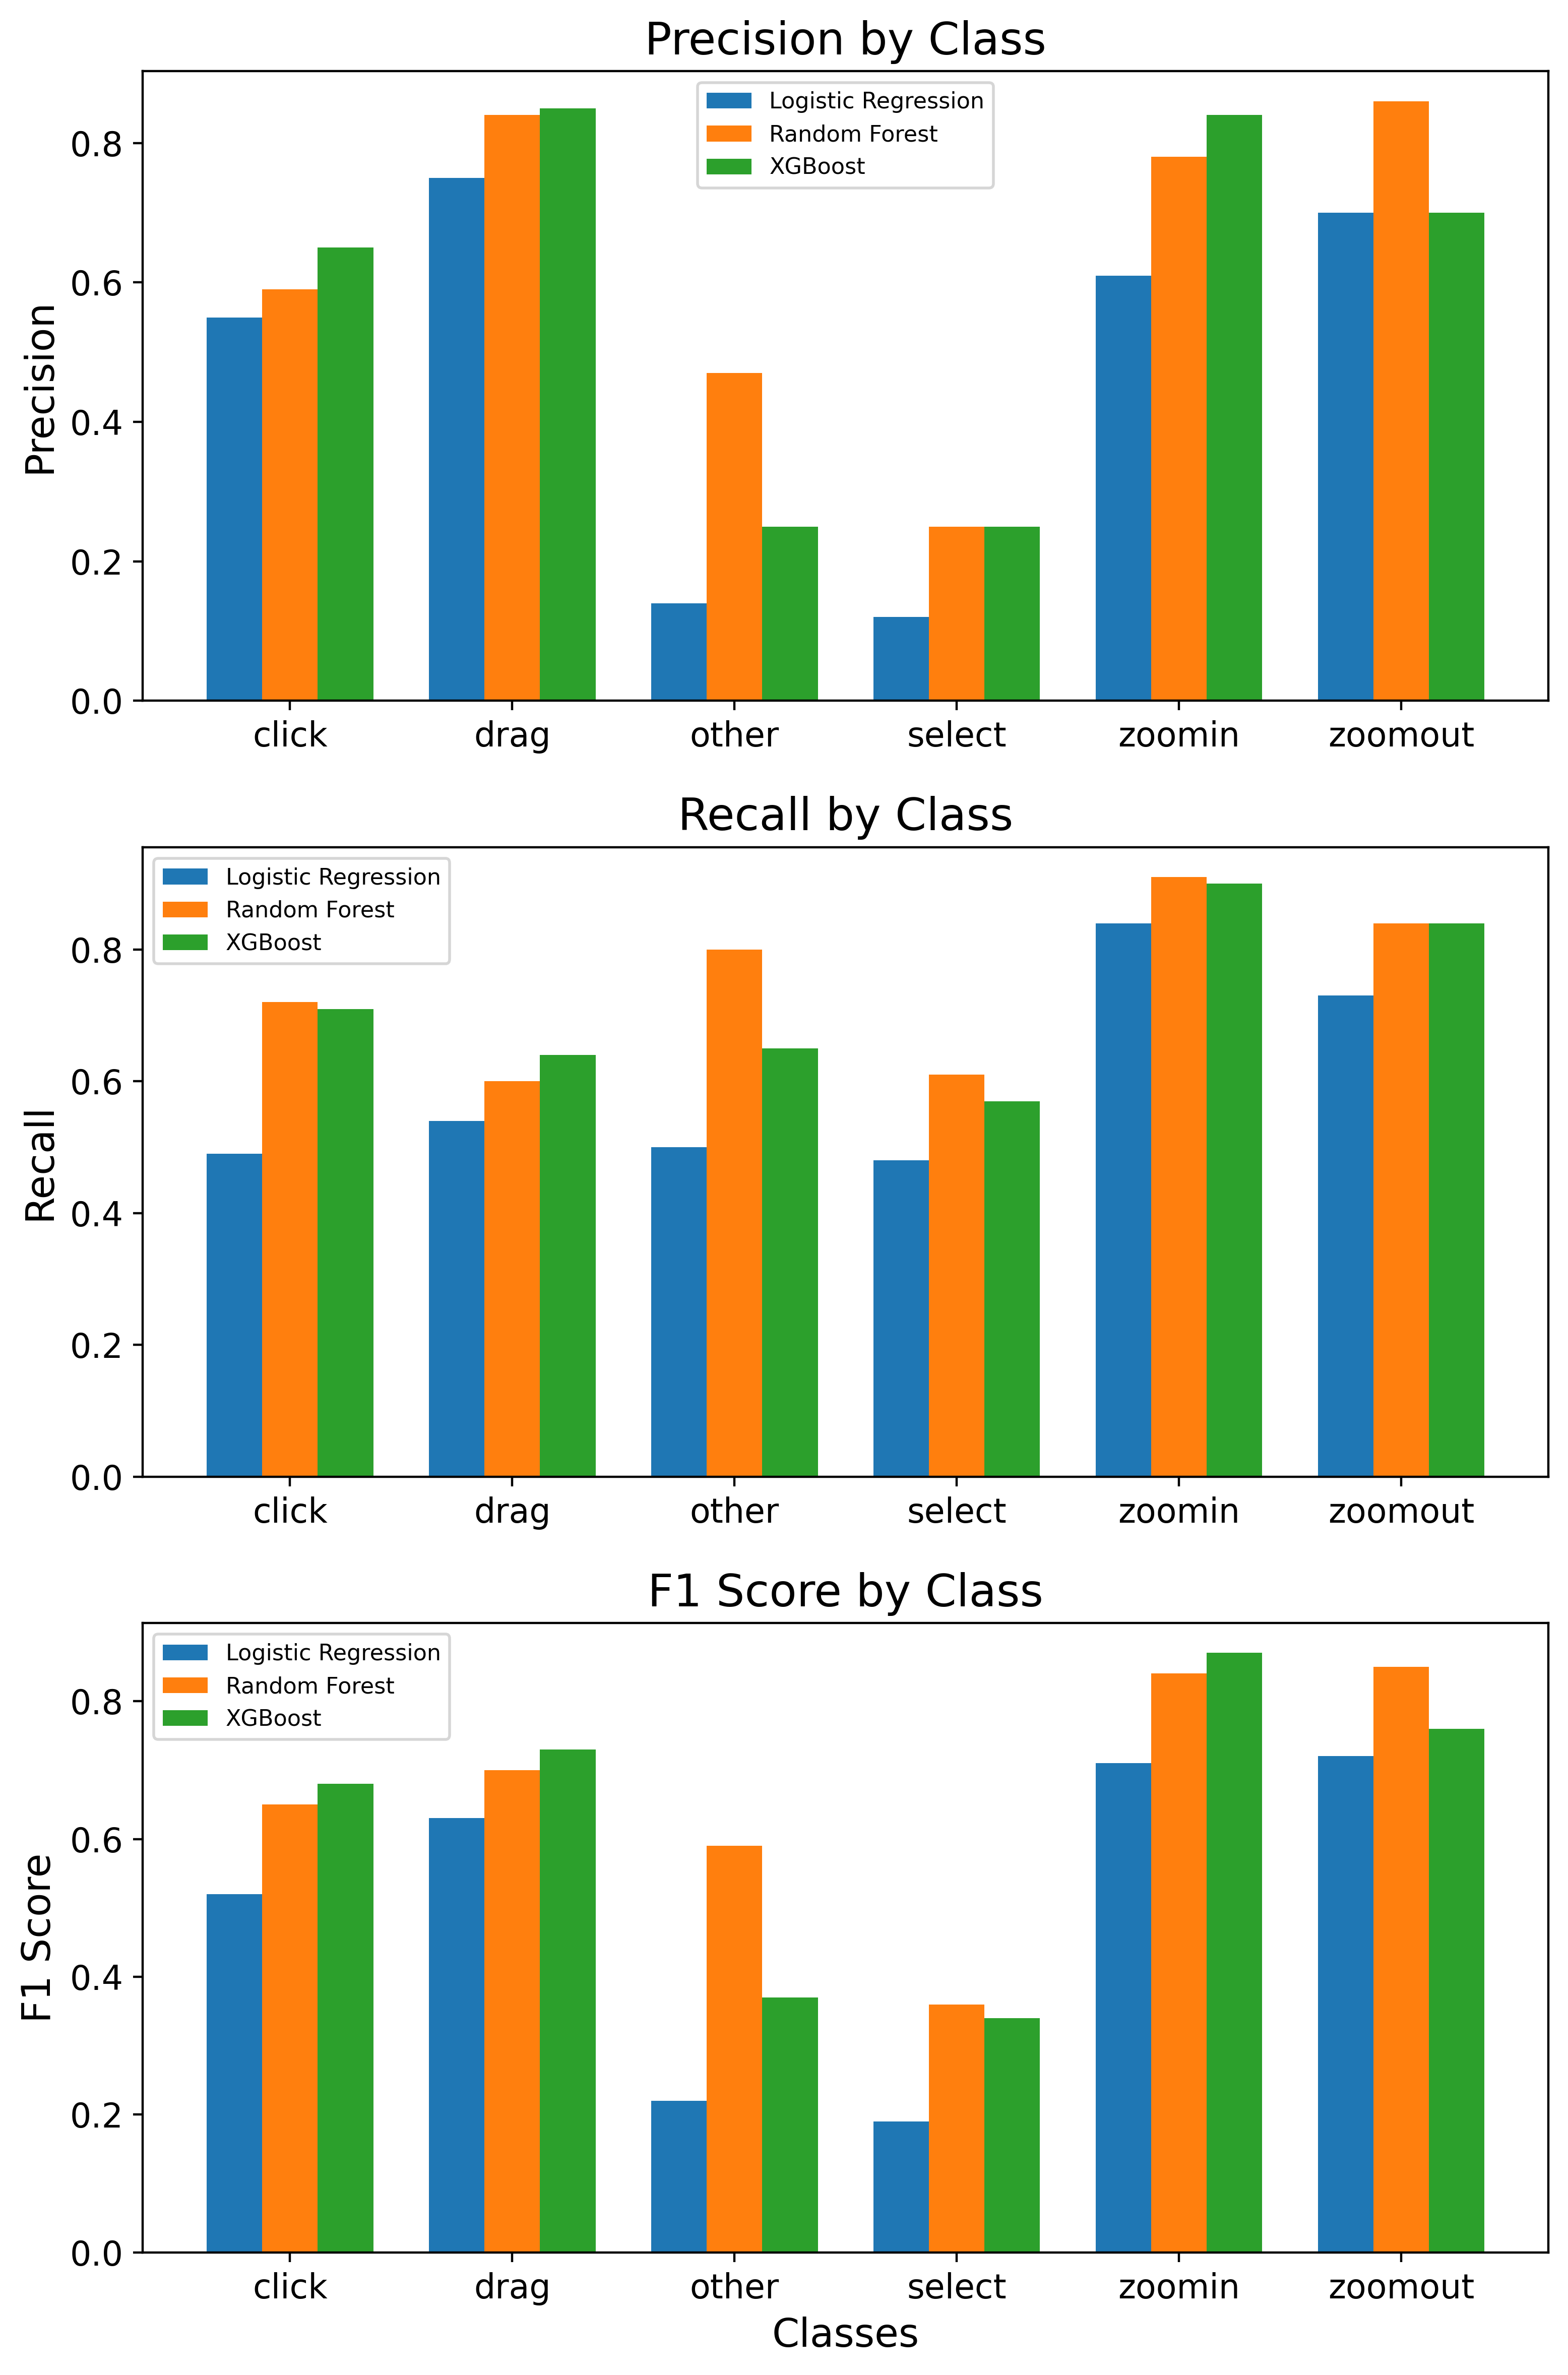

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = ['click', 'drag', 'other', 'select', 'zoomin', 'zoomout']

# --- Metrics ---

# Precision
prec_logistic = [0.55, 0.75, 0.14, 0.12, 0.61, 0.70]
prec_rf = [0.59, 0.84, 0.47, 0.25, 0.78, 0.86]
prec_xgb = [0.65, 0.85, 0.25, 0.25, 0.84, 0.70]

# Recall
rec_logistic = [0.49, 0.54, 0.50, 0.48, 0.84, 0.73]
rec_rf = [0.72, 0.60, 0.80, 0.61, 0.91, 0.84]
rec_xgb = [0.71, 0.64, 0.65, 0.57, 0.90, 0.84]

# F1 Score
f1_logistic = [0.52, 0.63, 0.22, 0.19, 0.71, 0.72]
f1_rf = [0.65, 0.70, 0.59, 0.36, 0.84, 0.85]
f1_xgb = [0.68, 0.73, 0.37, 0.34, 0.87, 0.76]

# Positions of the bars
x = np.arange(len(classes))
width = 0.25

# --- Subplots ---
fig, axes = plt.subplots(3, 1, figsize=(8, 12), dpi=400)

# ---- Precision ----
axes[0].bar(x - width, prec_logistic, width, label='Logistic Regression')
axes[0].bar(x, prec_rf, width, label='Random Forest')
axes[0].bar(x + width, prec_xgb, width, label='XGBoost')
axes[0].set_title('Precision by Class')
axes[0].set_ylabel('Precision')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].legend()

# ---- Recall ----
axes[1].bar(x - width, rec_logistic, width, label='Logistic Regression')
axes[1].bar(x, rec_rf, width, label='Random Forest')
axes[1].bar(x + width, rec_xgb, width, label='XGBoost')
axes[1].set_title('Recall by Class')
axes[1].set_ylabel('Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].legend()

# ---- F1 Score ----
axes[2].bar(x - width, f1_logistic, width, label='Logistic Regression')
axes[2].bar(x, f1_rf, width, label='Random Forest')
axes[2].bar(x + width, f1_xgb, width, label='XGBoost')
axes[2].set_title('F1 Score by Class')
axes[2].set_ylabel('F1 Score')
axes[2].set_xticks(x)
axes[2].set_xticklabels(classes)
axes[2].set_xlabel('Classes')
axes[2].legend()

plt.tight_layout()
plt.savefig("figures/figure_2.pdf")
plt.show()